In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
print("All libraries imported successfully!")

All libraries imported successfully!


In [2]:
df = sns.load_dataset("titanic")
print("Dataset loaded successfully!")
print("Shape:", df.shape)
df.to_csv("titanic.csv", index=False)
print("Offline fallback saved as analytics/titanic.csv")

Dataset loaded successfully!
Shape: (891, 15)
Offline fallback saved as analytics/titanic.csv


In [3]:
print("========== DATASET INFO ==========")
df.info()
print("\n========== DESCRIPTIVE STATISTICS ==========")
print(df.describe())
print("\n========== DATASET SHAPE ==========")
print(df.shape)
print("\n========== MISSING VALUES ==========")
missing = df.isnull().sum()
missing_percentage = (df.isnull().mean() * 100)
missing_report = pd.DataFrame({
    "missing_count": missing,
    "missing_percentage": missing_percentage
})
missing_report = missing_report[
    missing_report["missing_count"] > 0
].sort_values(
    "missing_percentage",
    ascending=False
)
print(missing_report)

========== DATASET INFO ==========
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB

========== DESCRIPTIVE STATISTICS =========

In [4]:
# Make a copy so the original loaded DataFrame remains available
cleaned_df = df.copy()
# 1. Drop the high-missingness deck column
cleaned_df = cleaned_df.drop(columns=["deck"])
# 2. Impute missing age values with the median
age_median = cleaned_df["age"].median()
cleaned_df["age"] = cleaned_df["age"].fillna(age_median)
# 3. Drop rows with missing embarked and embark_town values
cleaned_df = cleaned_df.dropna(subset=["embarked", "embark_town"])
print("========== CLEANING COMPLETED ==========")
print("Original shape:", df.shape)
print("Cleaned shape:", cleaned_df.shape)
print("\nMissing values after cleaning:")
print(cleaned_df.isnull().sum())
print("\nMedian used for age imputation:", age_median)

========== CLEANING COMPLETED ==========
Original shape: (891, 15)
Cleaned shape: (889, 14)

Missing values after cleaning:
survived       0
pclass         0
sex            0
age            0
sibsp          0
parch          0
fare           0
embarked       0
class          0
who            0
adult_male     0
embark_town    0
alive          0
alone          0
dtype: int64

Median used for age imputation: 28.0


In [5]:
# Save cleaned dataset for EDA reference
cleaned_df.to_csv("cleaned_titanic.csv", index=False)
print("Cleaned dataset saved successfully!")
print("Shape:", cleaned_df.shape)

Cleaned dataset saved successfully!
Shape: (889, 14)


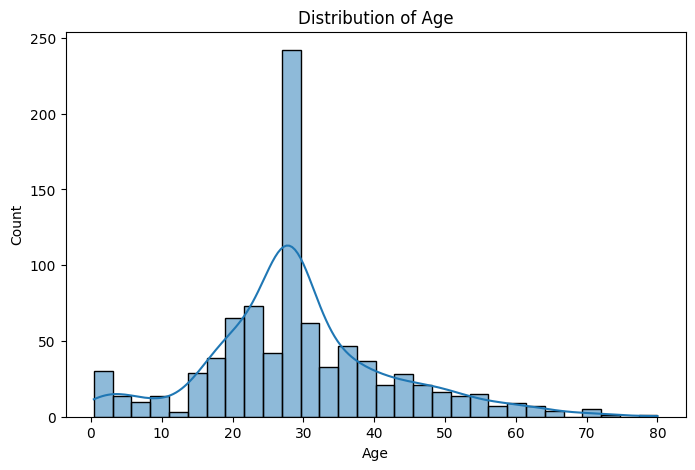

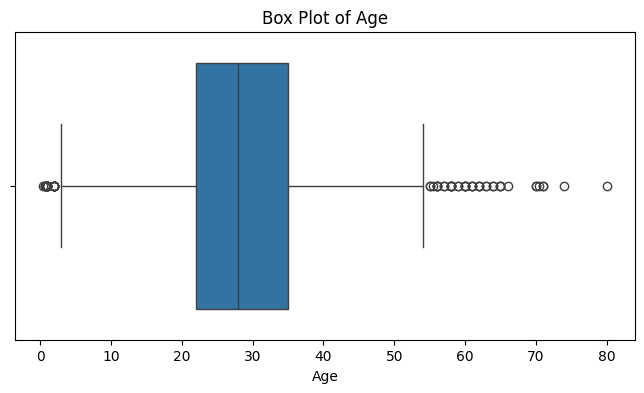

Age Q1: 22.0
Age Q3: 35.0
Age IQR: 13.0
Age lower bound: 2.5
Age upper bound: 54.5
Number of age outliers: 65


In [6]:
# =========================
# UNIVARIATE ANALYSIS: AGE
# =========================
plt.figure(figsize=(8, 5))
sns.histplot(cleaned_df["age"], bins=30, kde=True)
plt.title("Distribution of Age")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()
plt.figure(figsize=(8, 4))
sns.boxplot(x=cleaned_df["age"])
plt.title("Box Plot of Age")
plt.xlabel("Age")
plt.show()
# IQR outlier calculation
Q1_age = cleaned_df["age"].quantile(0.25)
Q3_age = cleaned_df["age"].quantile(0.75)
IQR_age = Q3_age - Q1_age
lower_age = Q1_age - 1.5 * IQR_age
upper_age = Q3_age + 1.5 * IQR_age
age_outliers = cleaned_df[
    (cleaned_df["age"] < lower_age) |
    (cleaned_df["age"] > upper_age)
]
print("Age Q1:", Q1_age)
print("Age Q3:", Q3_age)
print("Age IQR:", IQR_age)
print("Age lower bound:", lower_age)
print("Age upper bound:", upper_age)
print("Number of age outliers:", len(age_outliers))

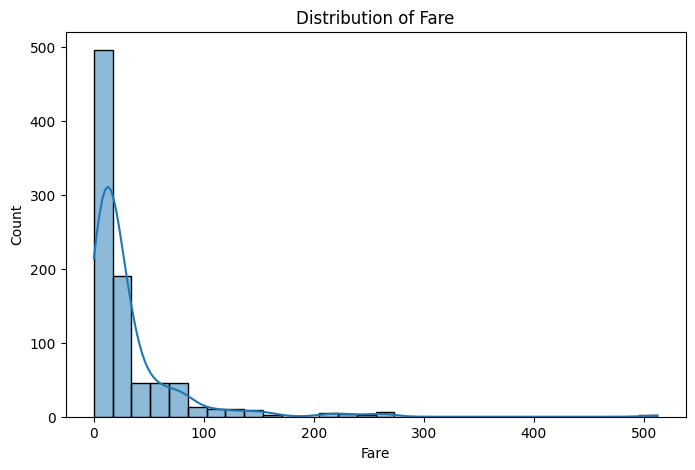

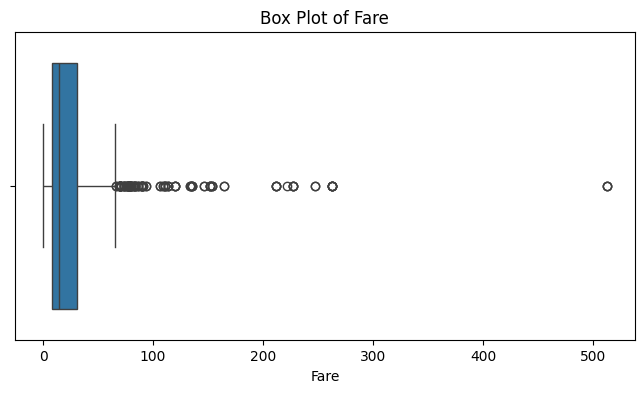

Fare Q1: 7.8958
Fare Q3: 31.0
Fare IQR: 23.1042
Fare lower bound: -26.7605
Fare upper bound: 65.6563
Number of fare outliers: 114

========== FARE SUMMARY STATISTICS ==========
Mean: 32.09668087739032
Median: 14.4542
Mode: 8.05
Skewness: 4.801440211044194


In [7]:
# =========================
# UNIVARIATE ANALYSIS: FARE
# =========================
plt.figure(figsize=(8, 5))
sns.histplot(cleaned_df["fare"], bins=30, kde=True)
plt.title("Distribution of Fare")
plt.xlabel("Fare")
plt.ylabel("Count")
plt.show()
plt.figure(figsize=(8, 4))
sns.boxplot(x=cleaned_df["fare"])
plt.title("Box Plot of Fare")
plt.xlabel("Fare")
plt.show()
# IQR outlier calculation
Q1_fare = cleaned_df["fare"].quantile(0.25)
Q3_fare = cleaned_df["fare"].quantile(0.75)
IQR_fare = Q3_fare - Q1_fare
lower_fare = Q1_fare - 1.5 * IQR_fare
upper_fare = Q3_fare + 1.5 * IQR_fare
fare_outliers = cleaned_df[
    (cleaned_df["fare"] < lower_fare) |
    (cleaned_df["fare"] > upper_fare)
]
print("Fare Q1:", Q1_fare)
print("Fare Q3:", Q3_fare)
print("Fare IQR:", IQR_fare)
print("Fare lower bound:", lower_fare)
print("Fare upper bound:", upper_fare)
print("Number of fare outliers:", len(fare_outliers))
print("\n========== FARE SUMMARY STATISTICS ==========")
print("Mean:", cleaned_df["fare"].mean())
print("Median:", cleaned_df["fare"].median())
print("Mode:", cleaned_df["fare"].mode().iloc[0])
print("Skewness:", cleaned_df["fare"].skew())

In [8]:
# =========================
# BIVARIATE ANALYSIS
# SURVIVAL RATES
# =========================
# Survival rate by sex
female_mask = cleaned_df["sex"] == "female"
male_mask = cleaned_df["sex"] == "male"
female_survival = cleaned_df.loc[female_mask, "survived"].mean()
male_survival = cleaned_df.loc[male_mask, "survived"].mean()
print("========== SURVIVAL RATE BY SEX ==========")
print("Female:", female_survival)
print("Male:", male_survival)
# Survival rate by passenger class
first_class_mask = cleaned_df["pclass"] == 1
second_class_mask = cleaned_df["pclass"] == 2
third_class_mask = cleaned_df["pclass"] == 3
print("\n========== SURVIVAL RATE BY PCLASS ==========")
print("1st Class:", cleaned_df.loc[first_class_mask, "survived"].mean())
print("2nd Class:", cleaned_df.loc[second_class_mask, "survived"].mean())
print("3rd Class:", cleaned_df.loc[third_class_mask, "survived"].mean())
# Survival rate by sex AND passenger class
female_first = cleaned_df[
    (cleaned_df["sex"] == "female") &
    (cleaned_df["pclass"] == 1)
]
female_second = cleaned_df[
    (cleaned_df["sex"] == "female") &
    (cleaned_df["pclass"] == 2)
]
female_third = cleaned_df[
    (cleaned_df["sex"] == "female") &
    (cleaned_df["pclass"] == 3)
]
male_first = cleaned_df[
    (cleaned_df["sex"] == "male") &
    (cleaned_df["pclass"] == 1)
]
male_second = cleaned_df[
    (cleaned_df["sex"] == "male") &
    (cleaned_df["pclass"] == 2)
]
male_third = cleaned_df[
    (cleaned_df["sex"] == "male") &
    (cleaned_df["pclass"] == 3)
]
print("\n========== SURVIVAL RATE BY SEX + PCLASS ==========")
print("Female, 1st Class:", female_first["survived"].mean())
print("Female, 2nd Class:", female_second["survived"].mean())
print("Female, 3rd Class:", female_third["survived"].mean())
print("Male, 1st Class:", male_first["survived"].mean())
print("Male, 2nd Class:", male_second["survived"].mean())
print("Male, 3rd Class:", male_third["survived"].mean())

========== SURVIVAL RATE BY SEX ==========
Female: 0.7403846153846154
Male: 0.18890814558058924

========== SURVIVAL RATE BY PCLASS ==========
1st Class: 0.6261682242990654
2nd Class: 0.47282608695652173
3rd Class: 0.24236252545824846

========== SURVIVAL RATE BY SEX + PCLASS ==========
Female, 1st Class: 0.967391304347826
Female, 2nd Class: 0.9210526315789473
Female, 3rd Class: 0.5
Male, 1st Class: 0.36885245901639346
Male, 2nd Class: 0.1574074074074074
Male, 3rd Class: 0.13544668587896252


========== CORRELATION MATRIX ==========
          survived    pclass       age     sibsp     parch      fare
survived  1.000000 -0.335549 -0.069822 -0.034040  0.083151  0.255290
pclass   -0.335549  1.000000 -0.336512  0.081656  0.016824 -0.548193
age      -0.069822 -0.336512  1.000000 -0.232543 -0.171485  0.093707
sibsp    -0.034040  0.081656 -0.232543  1.000000  0.414542  0.160887
parch     0.083151  0.016824 -0.171485  0.414542  1.000000  0.217532
fare      0.255290 -0.548193  0.093707  0.160887  0.217532  1.000000


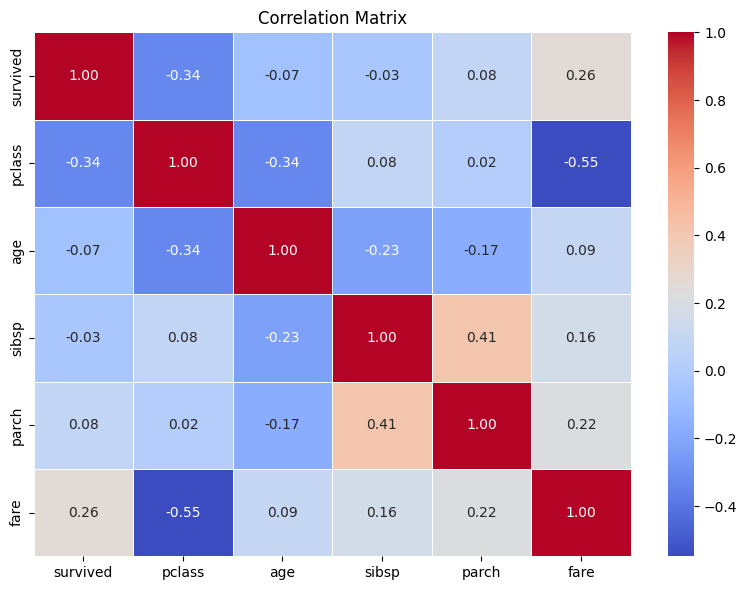


========== STRONGEST CORRELATIONS ==========
pclass ↔ fare: 0.5482
sibsp ↔ parch: 0.4145
age ↔ pclass: 0.3365
pclass ↔ survived: 0.3355
fare ↔ survived: 0.2553


In [9]:
# =========================
# CORRELATION ANALYSIS
# =========================
correlation_columns = [
    "survived",
    "pclass",
    "age",
    "sibsp",
    "parch",
    "fare"
]
correlation_matrix = cleaned_df[correlation_columns].corr()
print("========== CORRELATION MATRIX ==========")
print(correlation_matrix)
# Heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5
)
plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()
# Find strongest absolute off-diagonal correlations
corr_pairs = (
    correlation_matrix
    .where(~np.eye(correlation_matrix.shape[0], dtype=bool))
    .stack()
    .abs()
    .sort_values(ascending=False)
)
print("\n========== STRONGEST CORRELATIONS ==========")
# Remove duplicate pairs
seen = set()
count = 0
for pair_value in corr_pairs.items():
    pair, value = pair_value
    pair_set = frozenset(pair)
    if pair_set not in seen:
        seen.add(pair_set)
        print(f"{pair[0]} ↔ {pair[1]}: {value:.4f}")
        count += 1
    if count == 5:
        break

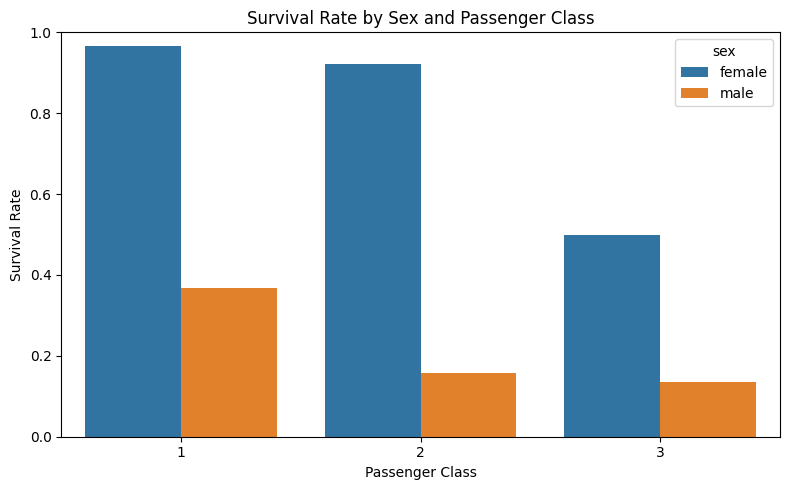

In [10]:
# ==========================================
# MULTIVARIATE CHART 1
# SURVIVAL RATE BY SEX AND PCLASS
# ==========================================
survival_by_sex_class = (
    cleaned_df
    .groupby(["sex", "pclass"])["survived"]
    .mean()
    .reset_index()
)
plt.figure(figsize=(8, 5))
sns.barplot(
    data=survival_by_sex_class,
    x="pclass",
    y="survived",
    hue="sex"
)
plt.title("Survival Rate by Sex and Passenger Class")
plt.xlabel("Passenger Class")
plt.ylabel("Survival Rate")
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

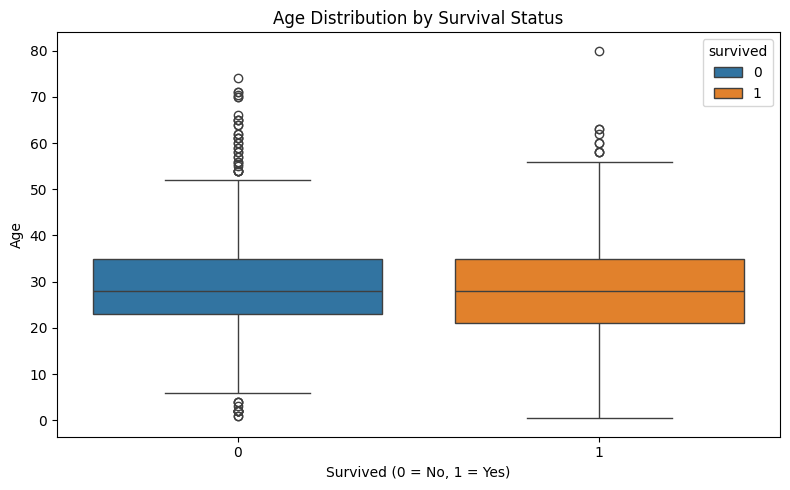

In [11]:
# ==========================================
# MULTIVARIATE CHART 2
# AGE DISTRIBUTION BY SURVIVAL STATUS
# ==========================================
plt.figure(figsize=(8, 5))
sns.boxplot(
    data=cleaned_df,
    x="survived",
    y="age",
    hue="survived"
)
plt.title("Age Distribution by Survival Status")
plt.xlabel("Survived (0 = No, 1 = Yes)")
plt.ylabel("Age")
plt.tight_layout()
plt.show()

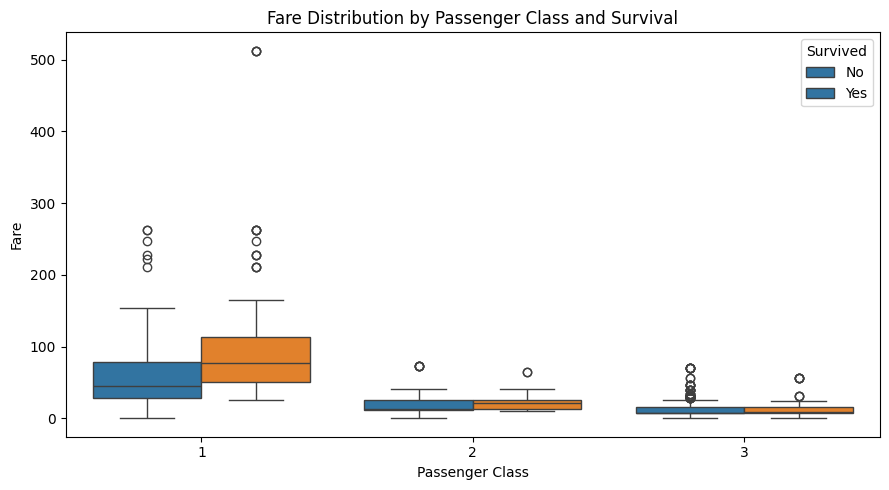

In [12]:
# ==========================================
# MULTIVARIATE CHART 3
# FARE BY PCLASS AND SURVIVAL
# ==========================================
plt.figure(figsize=(9, 5))

sns.boxplot(
    data=cleaned_df,
    x="pclass",
    y="fare",
    hue="survived"
)
plt.title("Fare Distribution by Passenger Class and Survival")
plt.xlabel("Passenger Class")
plt.ylabel("Fare")
plt.legend(title="Survived", labels=["No", "Yes"])
plt.tight_layout()
plt.show()

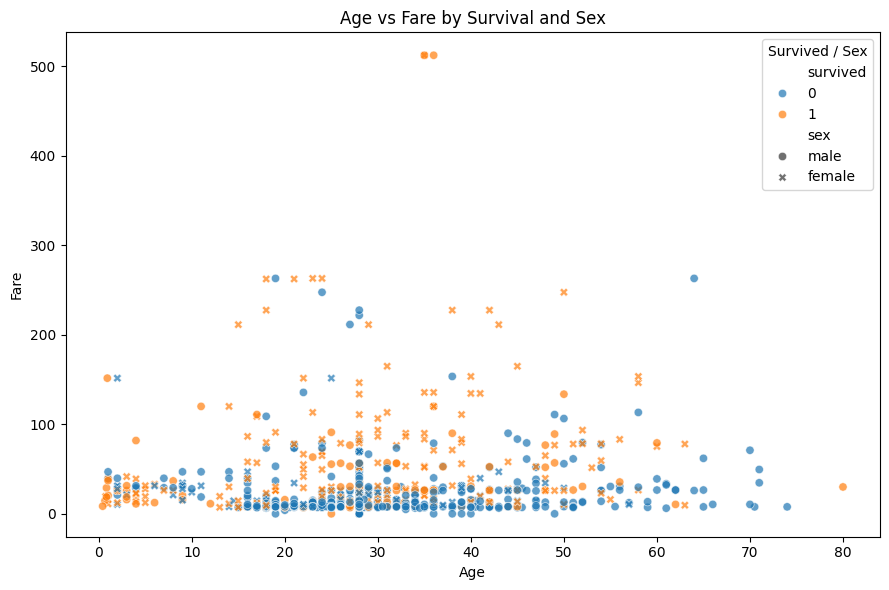

In [13]:
# ==========================================
# MULTIVARIATE CHART 4
# AGE VS FARE BY SURVIVAL
# ==========================================
plt.figure(figsize=(9, 6))
sns.scatterplot(
    data=cleaned_df,
    x="age",
    y="fare",
    hue="survived",
    style="sex",
    alpha=0.7
)
plt.title("Age vs Fare by Survival and Sex")
plt.xlabel("Age")
plt.ylabel("Fare")
plt.legend(title="Survived / Sex")
plt.tight_layout()
plt.show()

In [14]:
# ==========================================
# EDA-ONLY STANDARDIZATION
# ==========================================

# Keep original values for comparison
age_before_mean = cleaned_df["age"].mean()
age_before_std = cleaned_df["age"].std()
fare_before_mean = cleaned_df["fare"].mean()
fare_before_std = cleaned_df["fare"].std()
# Standardize age and fare
scaler = StandardScaler()
standardized_values = scaler.fit_transform(
    cleaned_df[["age", "fare"]]
)
standardized_df = cleaned_df.copy()
standardized_df[["age", "fare"]] = standardized_values
print("========== BEFORE STANDARDIZATION ==========")
print("Age mean:", age_before_mean)
print("Age std:", age_before_std)
print("Fare mean:", fare_before_mean)
print("Fare std:", fare_before_std)
print("\n========== AFTER STANDARDIZATION ==========")
print("Age mean:", standardized_df["age"].mean())
print("Age std:", standardized_df["age"].std())
print("Fare mean:", standardized_df["fare"].mean())
print("Fare std:", standardized_df["fare"].std())

========== BEFORE STANDARDIZATION ==========
Age mean: 29.315151856017994
Age std: 12.984932293690775
Fare mean: 32.09668087739032
Fare std: 49.697504316707956

========== AFTER STANDARDIZATION ==========
Age mean: 2.717486278497571e-16
Age std: 1.0005629046322504
Fare mean: 1.3987061727561027e-16
Fare std: 1.0005629046322506


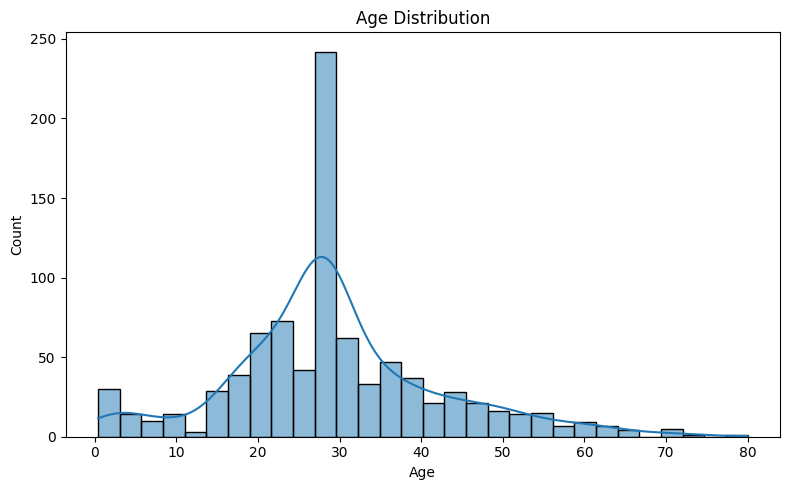

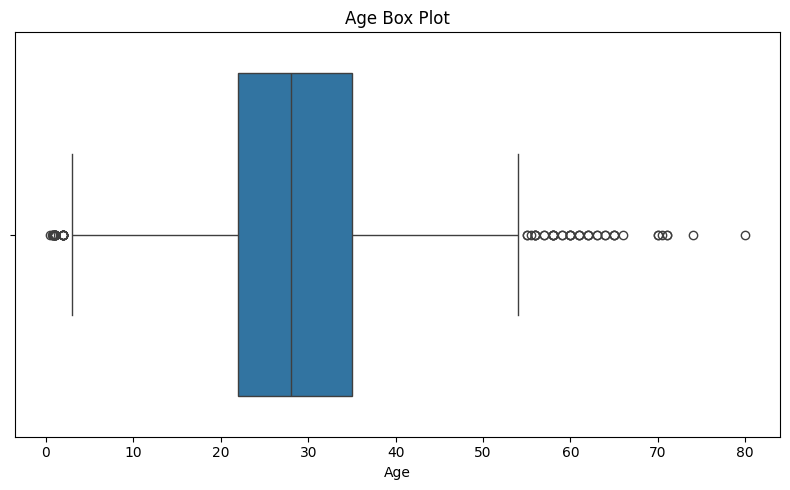

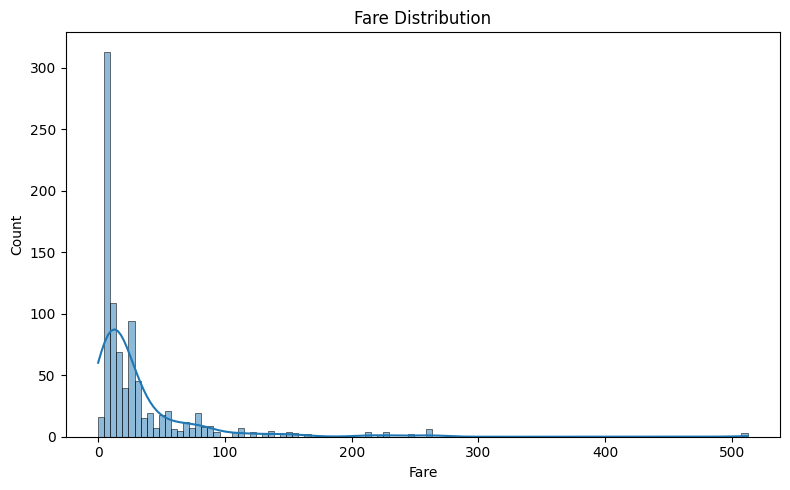

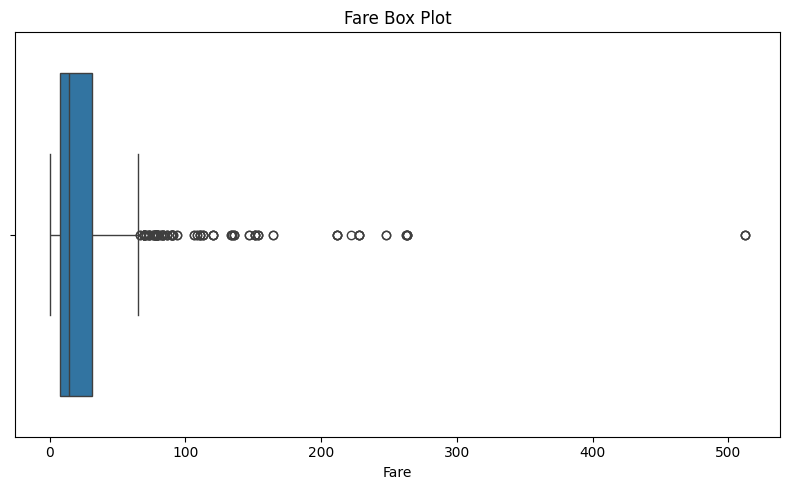

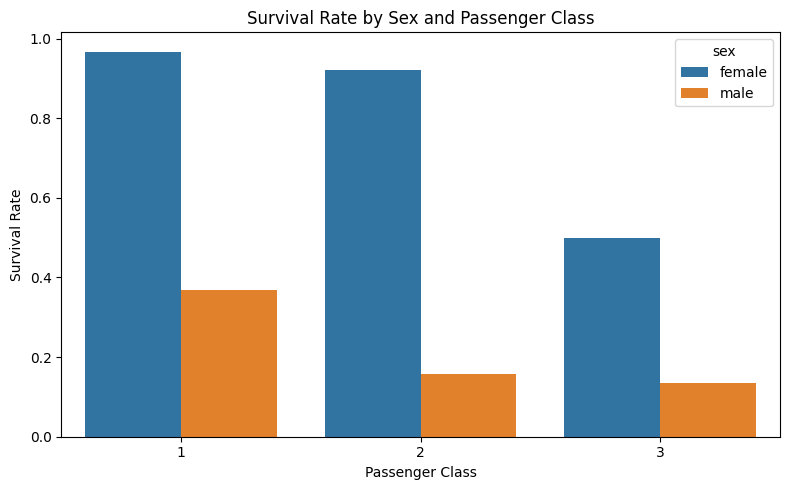

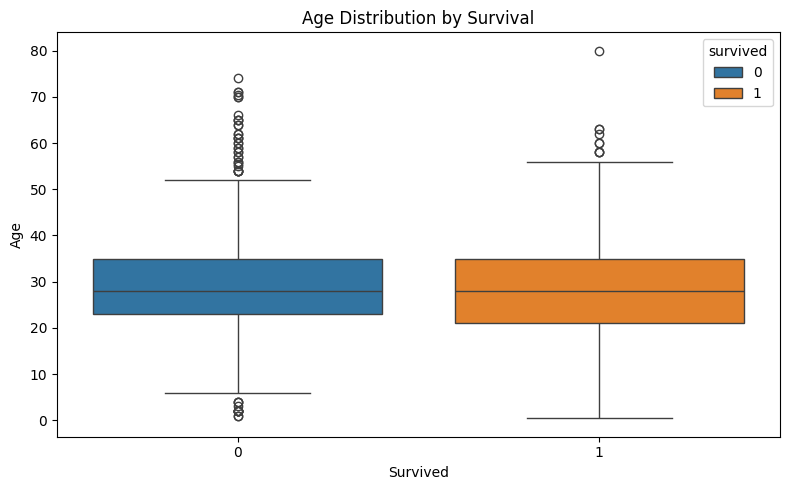

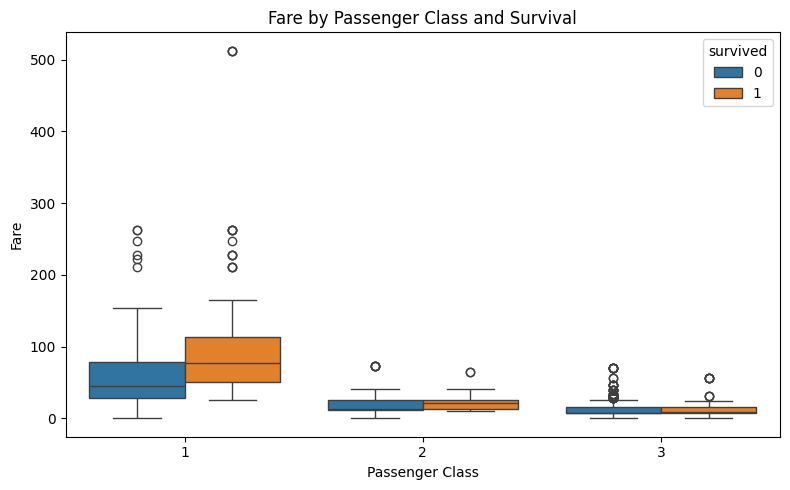

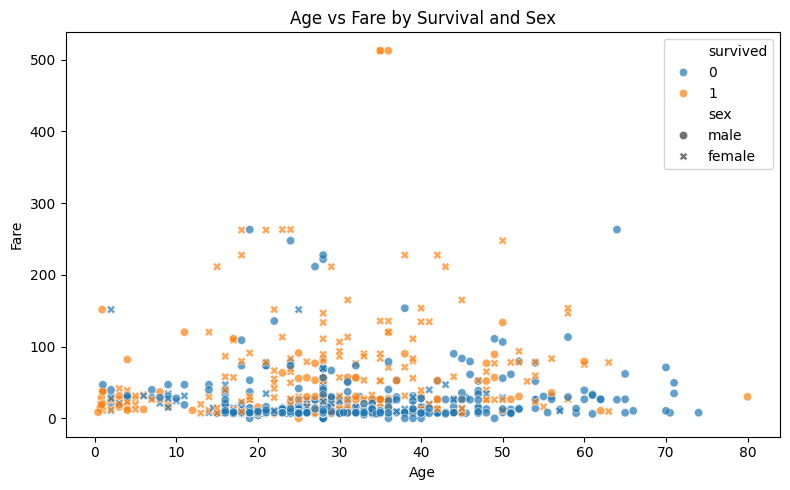

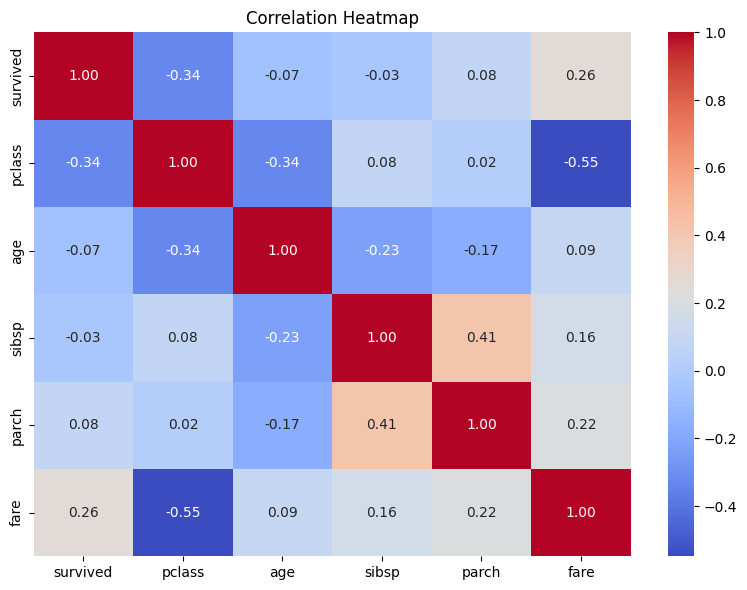

All EDA charts saved successfully!


In [15]:
import os
os.makedirs("charts", exist_ok=True)

# 1. Age distribution
plt.figure(figsize=(8, 5))
sns.histplot(cleaned_df["age"], kde=True)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig("charts/age_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

# 2. Age box plot
plt.figure(figsize=(8, 5))
sns.boxplot(x=cleaned_df["age"])
plt.title("Age Box Plot")
plt.xlabel("Age")
plt.tight_layout()
plt.savefig("charts/age_boxplot.png", dpi=300, bbox_inches="tight")
plt.show()

# 3. Fare distribution
plt.figure(figsize=(8, 5))
sns.histplot(cleaned_df["fare"], kde=True)
plt.title("Fare Distribution")
plt.xlabel("Fare")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig("charts/fare_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

# 4. Fare box plot
plt.figure(figsize=(8, 5))
sns.boxplot(x=cleaned_df["fare"])
plt.title("Fare Box Plot")
plt.xlabel("Fare")
plt.tight_layout()
plt.savefig("charts/fare_boxplot.png", dpi=300, bbox_inches="tight")
plt.show()

# 5. Survival by sex and class
plt.figure(figsize=(8, 5))
sns.barplot(
    data=survival_by_sex_class,
    x="pclass",
    y="survived",
    hue="sex"
)
plt.title("Survival Rate by Sex and Passenger Class")
plt.xlabel("Passenger Class")
plt.ylabel("Survival Rate")
plt.tight_layout()
plt.savefig("charts/survival_by_sex_class.png", dpi=300, bbox_inches="tight")
plt.show()

# 6. Age by survival
plt.figure(figsize=(8, 5))
sns.boxplot(
    data=cleaned_df,
    x="survived",
    y="age",
    hue="survived"
)
plt.title("Age Distribution by Survival")
plt.xlabel("Survived")
plt.ylabel("Age")
plt.tight_layout()
plt.savefig("charts/age_by_survival.png", dpi=300, bbox_inches="tight")
plt.show()

# 7. Fare by class and survival
plt.figure(figsize=(8, 5))
sns.boxplot(
    data=cleaned_df,
    x="pclass",
    y="fare",
    hue="survived"
)
plt.title("Fare by Passenger Class and Survival")
plt.xlabel("Passenger Class")
plt.ylabel("Fare")
plt.tight_layout()
plt.savefig("charts/fare_by_pclass_survival.png", dpi=300, bbox_inches="tight")
plt.show()

# 8. Age vs Fare
plt.figure(figsize=(8, 5))
sns.scatterplot(
    data=cleaned_df,
    x="age",
    y="fare",
    hue="survived",
    style="sex",
    alpha=0.7
)
plt.title("Age vs Fare by Survival and Sex")
plt.xlabel("Age")
plt.ylabel("Fare")
plt.tight_layout()
plt.savefig("charts/age_vs_fare_survival_sex.png", dpi=300, bbox_inches="tight")
plt.show()

# 9. Correlation heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(
    cleaned_df[
        ["survived", "pclass", "age", "sibsp", "parch", "fare"]
    ].corr(),
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.savefig("charts/correlation_heatmap.png", dpi=300, bbox_inches="tight")
plt.show()

print("All EDA charts saved successfully!")

## EDA Findings and Interpretations

### Missing-value handling

I used the following percentage-based rule for missing values:

* If a column has more than 50% missing values, I drop the column because too much information is missing.
* If a numeric column has between 5% and 50% missing values, I use median imputation.
* If a categorical column has less than 5% missing values, I remove the affected rows because the number of rows removed is very small.

Using this rule, `deck` had 77.22% missing values, so I dropped it. `age` had 19.87% missing values, so I filled the missing values using the median. `embarked` and `embark_town` each had 0.22% missing values, so I removed the affected rows.

### Fare distribution

The fare distribution is strongly right-skewed. The mean fare is 32.0967, while the median is 14.4542 and the mode is 8.05. Since the mean is much higher than the median and mode, a small number of high fares are pulling the mean upward. The skewness value of 4.8014 also confirms strong positive skewness.

### Survival rate by sex and passenger class

The survival rate is different across sex and passenger class. Female passengers had a much higher survival rate than male passengers. Survival also generally decreased from 1st class to 3rd class.

The combined analysis shows that sex and passenger class both have a clear relationship with survival. For example, female passengers in 1st and 2nd class had very high survival rates, while male passengers had much lower rates across all classes.

### Age distribution by survival status

The age box plot shows differences in the age distributions of passengers who survived and those who did not. The two groups overlap, so age alone does not completely separate survivors from non-survivors.

### Fare by passenger class and survival

The fare distribution differs across passenger classes. Higher passenger classes generally have higher fares. Within the classes, survivors tend to have different fare distributions from non-survivors, showing that fare and passenger class contain useful information related to survival.

### Age versus fare by survival and sex

The scatter plot shows the relationship between age and fare while also separating the observations by survival and sex. There is no strong simple linear relationship between age and fare, but the plot shows that survival patterns vary across different age and fare combinations.

### Correlation analysis

The two strongest absolute correlations are:

1. `pclass` and `fare`: correlation = -0.5482. This negative relationship means that lower numerical passenger-class values, which represent higher passenger classes, are generally associated with higher fares.
2. `sibsp` and `parch`: correlation = 0.4145. This positive relationship suggests that passengers with more siblings or spouses aboard also tended to have more parents or children aboard.

These correlations describe association and do not by themselves prove that one variable causes the other.

### Standardization check

Before standardization, age and fare had their original mean and standard deviation. After using `StandardScaler`, both variables had means very close to 0 and standard deviations close to 1.

This standardization was used only for exploratory analysis. The original cleaned dataset was kept unchanged for the rest of the EDA workflow.
